In [65]:
import kagglehub
import os
import shutil
import sklearn
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

In [52]:
IRIS_FOLDER = "data/iris"
IRIS_CSV=os.path.join(IRIS_FOLDER, "Iris.csv")
RANDOM_STATE = 42

In [53]:
if not os.path.exists(IRIS_FOLDER):
    path = kagglehub.dataset_download("uciml/iris")
    shutil.copytree(path, IRIS_FOLDER)
    print("Copied to", IRIS_FOLDER)
else:
    print("Already exists, skipping.")
os.listdir(IRIS_FOLDER)

Already exists, skipping.


['Iris.csv', 'database.sqlite']

In [54]:
df = pd.read_csv(IRIS_CSV)
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


Separate the features (X) from the labels (y). As per requested from the assignment, we define the training, validation and test set with 70/15/15 split (X_train, y_train, X_val, y_val, X_test, y_test)

In [55]:
X = df.drop(columns=["Id", "Species"]).values
y = df["Species"].values
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE)

KMeans is applied on a range of clusters from 1 to 20 to determine the Intertia Elbow. The following code plots the Inertia versus Clusters and demonstrate the elbow appears at 3 clusters.

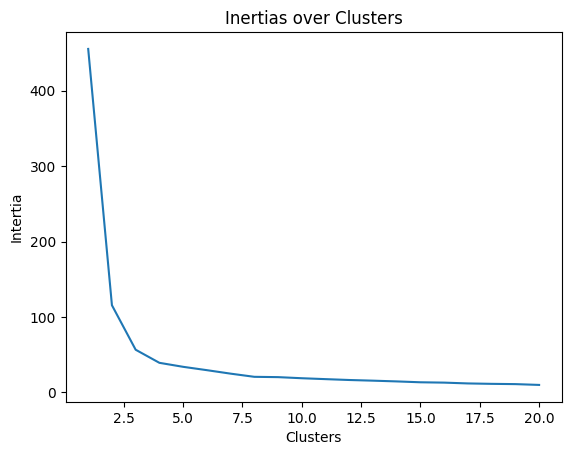

In [58]:
inertias = []
ks = range(1,21)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    km.fit(X_train)
    inertias.append(km.inertia_)

plt.plot(ks, inertias)
plt.title("Inertias over Clusters")
plt.xlabel("Clusters")
plt.ylabel("Intertia")
plt.show()

We recreate the KMeans model with 3 clusters and generate the confusion matrix.
As we can see below, the confusion matrix demonstrates which cluster matches best with each label.

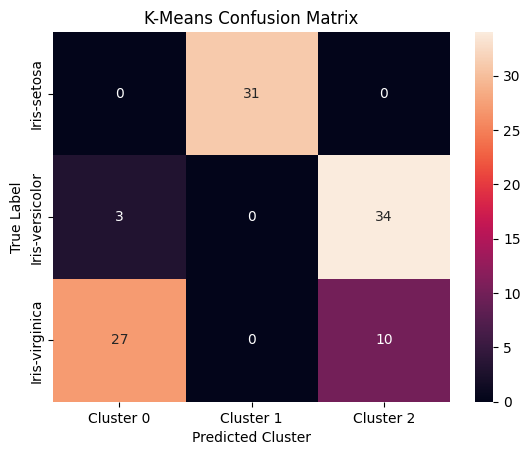

In [67]:
# recreate kmeans with cluster size 3 and train the model
km = KMeans(n_clusters=3, random_state=42)
km.fit(X_train)

# encode the y_train labels to numbers
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# create the confusion matrix
cm = confusion_matrix(y_train_encoded, km.labels_)

sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2'],
            yticklabels=le.classes_)
plt.xlabel('Predicted Cluster')
plt.ylabel('True Label')
plt.title('K-Means Confusion Matrix')
plt.show()